# STEP 5. H2 핵심 EDA

> **H2**: 골목상권의 순감소 위험이 높은 업종의 경우, 점포 규모와 유동인구를 맞추면 타 업종과 순감소 격차가 줄어들 것이다.

여기서 하는 일은 **매칭이 필요한지, 매칭이 가능한지**를 매칭 전에 확인하는 것입니다.

## 변수 역할

| 변수 | 원본 | 역할 |
|---|---|---|
| `y` | 점포-상권 (개업·폐업) | 결과변수 |
| `서비스_업종_코드_명` | 점포-상권 | 처리변수 |
| `log_점포수` | 점포-상권 `전체_점포_수` | **매칭 공변량 ①** ★H2 명시 |
| `log_유동인구` | 길단위인구-상권 | **매칭 공변량 ②** ★H2 명시 |
| `log_면적` | 영역-상권 | 매칭 공변량 ③ |
| `log_집객시설` | 집객시설-상권 | 매칭 공변량 ④ |

## 진행 순서

5-1 처리군 결정 → **5-2 처리군 선택 안정성** → 5-3 단순 격차 → 5-4 규모 교란 진단 → 5-5 SMD → 5-6 공통지지영역 → 5-7 단면 검정

> STEP 4 에서 1위(한식)와 2위(커피-음료) 격차가 **0.9%p** 로 좁았습니다. 처리군을 데이터가 정하게 하는 설계이므로, **그 결정이 표본 흔들림에 얼마나 견디는지**를 5-2 에서 먼저 확인합니다. 여기가 약하면 이후 ATT 는 "한식의 효과"가 아니라 "우연히 1위가 된 업종의 효과"가 됩니다.


In [1]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [2]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from config import PROC, FIG, TARGET_TYPE, COVARIATES, set_korean_font
set_korean_font()
OUT = FIG.parent
SEED = 42

def smd(a, b):
    """표준화 평균차. |SMD| < 0.1 이면 균형"""
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

d = pd.read_pickle(PROC / "03_panel.pkl")
d = d.drop(columns=[c for c in ["매출결측"] if c in d.columns])

gm = d[d["상권유형"] == TARGET_TYPE].copy()
print(f"{TARGET_TYPE} 요식업 표본 {len(gm):,}행 | 순감소율 {gm['y'].mean():.1%}")
print(f"상권 {gm['상권_코드'].nunique()}개 · 분기 {gm['기준_년분기_코드'].nunique()}개")

골목상권 요식업 표본 34,647행 | 순감소율 23.6%
상권 928개 · 분기 12개


## 5-1. 업종별 순감소율 → 처리군 결정

처리군을 미리 정하지 않고 **데이터가 고르게** 합니다. 임의로 골랐다는 인상을 피하기 위해서입니다.

In [3]:
t = (gm.groupby("서비스_업종_코드_명")
     .agg(순감소율=("y", "mean"), 칸수=("y", "size"),
          평균점포=("전체_점포_수", "mean"), 중앙유동인구=("총_유동인구_수", "median"),
          프랜차이즈비율=("프랜차이즈_비율", "mean"))
     .sort_values("순감소율", ascending=False))
display(t.round(3))

TREAT = t.index[0]
gm["처리"] = (gm["서비스_업종_코드_명"] == TREAT).astype(int)
margin = t.iloc[0]["순감소율"] - t.iloc[1]["순감소율"]
print(f"→ 처리군: {TREAT} ({t.iloc[0]['순감소율']:.1%})")
print(f"   2위 {t.index[1]} ({t.iloc[1]['순감소율']:.1%}), 격차 {margin:+.1%}p")

,순감소율,칸수,평균점포,중앙유동인구,프랜차이즈비율
서비스_업종_코드_명,,,,,
한식음식점,0.253,9957,21.315,779241.0,0.097
커피-음료,0.244,7741,12.595,893978.0,0.181
호프-간이주점,0.239,4596,11.783,1170658.0,0.092
패스트푸드점,0.237,1440,7.090,1515928.5,0.502
양식음식점,0.228,1478,11.118,1305611.5,0.068
분식전문점,0.222,3634,8.234,1264523.0,0.201
일식음식점,0.216,1036,8.420,1549588.5,0.122
제과점,0.206,1636,7.411,1319055.5,0.161
치킨전문점,0.201,1922,6.703,1391462.5,0.642


→ 처리군: 한식음식점 (25.3%)
   2위 커피-음료 (24.4%), 격차 +0.9%p


## 5-2. 처리군 선택 안정성 ★

1위와 2위 격차가 좁으면 "데이터가 정한 처리군"이 사실상 우연일 수 있습니다. 두 가지로 확인합니다.

- **분기별 1위** — 12분기 각각에서 누가 1위인가
- **클러스터 부트스트랩** — 상권을 복원추출해 1,000번 다시 순위를 매기면 누가 몇 번 1위인가 (같은 상권이 12분기 반복 관측되므로 상권 단위로 재표집)

In [5]:
# ① 분기별 1위
per_q = (gm.groupby(["기준_년분기_코드", "서비스_업종_코드_명"])["y"].mean()
         .unstack())
winner = per_q.idxmax(axis=1)
display(pd.DataFrame({"1위 업종": winner,
                      "1위 순감소율": per_q.max(axis=1).round(3),
                      f"{TREAT} 순위": per_q.rank(axis=1, ascending=False)[TREAT].astype(int)}))
print(f"{TREAT} (이)가 1위인 분기 : {(winner == TREAT).sum()} / {len(winner)}")

,1위 업종,1위 순감소율,한식음식점 순위
기준_년분기_코드,,,
20231,한식음식점,0.287,1
20232,패스트푸드점,0.284,3
20233,양식음식점,0.268,3
20234,제과점,0.252,10
20241,양식음식점,0.283,6
20242,패스트푸드점,0.309,4
20243,커피-음료,0.290,7
20244,패스트푸드점,0.322,2
20251,한식음식점,0.292,1


한식음식점 (이)가 1위인 분기 : 3 / 12


In [7]:
# ② 상권 단위 클러스터 부트스트랩
rng = np.random.default_rng(SEED)
areas = gm["상권_코드"].unique()
pos = {a: idx.to_numpy() for a, idx in gm.groupby("상권_코드").groups.items()}
yv  = gm["y"].to_numpy()
svc = gm["서비스_업종_코드_명"].to_numpy()

wins, top2 = {}, {}
B = 1000
for _ in range(B):
    sel = np.concatenate([pos[a] for a in rng.choice(areas, len(areas), replace=True)])
    loc = gm.index.get_indexer(sel)
    s = pd.Series(yv[loc]).groupby(svc[loc]).mean().sort_values(ascending=False)
    wins[s.index[0]] = wins.get(s.index[0], 0) + 1
    for nm in s.index[:2]:
        top2[nm] = top2.get(nm, 0) + 1

res = pd.DataFrame({"1위 빈도": pd.Series(wins), "상위2 빈도": pd.Series(top2)}).fillna(0)
res = (res / B).sort_values("1위 빈도", ascending=False)

display(res.round(3))
print(f"부트스트랩 {B}회 | {TREAT} 1위 비율 {res.loc[TREAT, '1위 빈도']:.1%}")
print("\n※ 1위 비율이 낮으면 ATT 를 '이 업종의 효과'로 단정하지 말고")
print("   '순감소율 상위권 업종의 효과'로 범위를 넓혀 보고해야 합니다.")

,1위 빈도,상위2 빈도
한식음식점,0.783,0.956
패스트푸드점,0.088,0.238
커피-음료,0.061,0.502
호프-간이주점,0.039,0.203
양식음식점,0.025,0.090
일식음식점,0.004,0.011


부트스트랩 1000회 | 한식음식점 1위 비율 78.3%

※ 1위 비율이 낮으면 ATT 를 '이 업종의 효과'로 단정하지 말고
   '순감소율 상위권 업종의 효과'로 범위를 넓혀 보고해야 합니다.


## 5-3. 매칭 전 단순 격차

H2 는 이 값이 매칭 후 줄어든다고 예측합니다.

In [8]:
p1 = gm.loc[gm["처리"] == 1, "y"].mean()
p0 = gm.loc[gm["처리"] == 0, "y"].mean()
gap = p1 - p0
print(f"처리군 {TREAT}    n={int(gm['처리'].sum()):,}   순감소율 {p1:.1%}")
print(f"대조군 기타 외식   n={int((1-gm['처리']).sum()):,}  순감소율 {p0:.1%}")
print(f"\n단순 격차 = {gap:+.1%}p")

처리군 한식음식점    n=9,957   순감소율 25.3%
대조군 기타 외식   n=24,690  순감소율 22.9%

단순 격차 = +2.4%p


## 5-4. 규모 교란 진단

격차가 업종 고유 위험이 아니라 규모 차이 때문일 수 있습니다. **규모 구간을 고정했을 때** 격차가 어떻게 변하는지 봅니다 — 매칭의 예고편입니다.

In [9]:
r = np.corrcoef(t["평균점포"], t["순감소율"])[0, 1]
print(f"업종 평균점포수 ↔ 순감소율 상관 r = {r:+.3f}")
print("r이 높으면 '업종 고유 위험'이 아니라 '규모 차이'일 가능성이 크다 → H2 지지 방향\n")

gm["규모구간"] = pd.qcut(gm["log_점포수"].rank(method="first"), 5,
                        labels=[f"Q{i}" for i in range(1, 6)])
piv = gm.pivot_table(index="규모구간", columns="처리", values="y",
                     aggfunc=["mean", "size"], observed=True)
tbl = pd.DataFrame({
    "대조군_순감소율": piv[("mean", 0)], "처리군_순감소율": piv[("mean", 1)],
    "대조n": piv[("size", 0)].astype("Int64"), "처리n": piv[("size", 1)].astype("Int64")})
tbl["격차"] = tbl["처리군_순감소율"] - tbl["대조군_순감소율"]
display(tbl.round(3))
print(f"단순 격차 {gap:+.1%}p → 구간 내 평균 격차 {tbl['격차'].mean():+.1%}p")
print("※ 구간 안에서 격차가 줄거나 뒤집히면 단순 격차가 규모 교란의 산물이라는 신호")

업종 평균점포수 ↔ 순감소율 상관 r = +0.657
r이 높으면 '업종 고유 위험'이 아니라 '규모 차이'일 가능성이 크다 → H2 지지 방향



,대조군_순감소율,처리군_순감소율,대조n,처리n,격차
규모구간,,,,,
Q1,0.153,0.107,6207,723,-0.047
Q2,0.184,0.142,5910,1019,-0.042
Q3,0.226,0.162,5453,1476,-0.064
Q4,0.304,0.242,4599,2330,-0.062
Q5,0.389,0.338,2521,4409,-0.051


단순 격차 +2.4%p → 구간 내 평균 격차 -5.3%p
※ 구간 안에서 격차가 줄거나 뒤집히면 단순 격차가 규모 교란의 산물이라는 신호


## 5-5. 공변량 균형 (SMD)

기준: |SMD| < 0.1 균형 / 0.1~0.25 불균형 / 0.25 초과 심각

매칭 **전** SMD 가 크다는 것 자체가 "두 집단이 원래 다른 조건에 분포해 있다"는 증거이고, PSM 이 필요한 이유입니다. 매칭 **후** 모든 공변량이 0.1 미만이 되어야 "조건을 맞췄다"고 말할 수 있습니다.

In [10]:
rows = []
for c in COVARIATES:
    a = gm.loc[gm["처리"] == 1, c]
    b = gm.loc[gm["처리"] == 0, c]
    s = smd(a, b)
    rows.append({"공변량": c, "처리군평균": a.mean(), "대조군평균": b.mean(), "SMD": s,
                 "판정": "균형" if abs(s) < 0.1 else ("불균형" if abs(s) < 0.25 else "심각한 불균형")})
bal = pd.DataFrame(rows)
display(bal.round(3))
bal.to_csv(OUT / "h2_balance_before.csv", index=False, encoding="utf-8-sig")
print(f"[저장] outputs/h2_balance_before.csv")

,공변량,처리군평균,대조군평균,SMD,판정
0,log_점포수,2.790,2.158,0.999,심각한 불균형
1,log_유동인구,13.410,13.824,-0.447,심각한 불균형
2,log_면적,11.345,11.653,-0.473,심각한 불균형
3,log_집객시설,2.515,2.841,-0.461,심각한 불균형


[저장] outputs/h2_balance_before.csv


## 5-6. 공통지지영역

매칭이 가능하려면 처리군과 대조군의 값 범위가 겹쳐야 합니다. 겹치지 않는 구간의 관측치는 PSM 에서 버려집니다.

**"격차가 줄었다"가 "격차를 만들던 관측치를 버렸다"일 수 있으므로**, 매칭 후 잔존 표본 수와 대표성을 반드시 함께 보고합니다.

In [11]:
for c in COVARIATES:
    a = gm.loc[gm["처리"] == 1, c]; b = gm.loc[gm["처리"] == 0, c]
    lo, hi = max(a.min(), b.min()), min(a.max(), b.max())
    keep = ((gm[c] >= lo) & (gm[c] <= hi)).mean()
    print(f"  {c:12} 겹치는 구간 [{lo:6.2f}, {hi:6.2f}]  → 표본의 {keep:.1%} 포함")

  log_점포수      겹치는 구간 [  1.61,   4.82]  → 표본의 100.0% 포함
  log_유동인구     겹치는 구간 [  2.20,  15.76]  → 표본의 100.0% 포함
  log_면적       겹치는 구간 [  9.12,  13.20]  → 표본의 99.9% 포함
  log_집객시설     겹치는 구간 [  0.00,   4.17]  → 표본의 100.0% 포함


## 5-7. 단면 카이제곱 + Cramér's V

전 분기를 풀링하면 같은 상권이 최대 12번 반복 관측되어 표본 크기가 인위적으로 부풀려집니다. 그러면 미미한 차이도 "유의하다"고 나옵니다. 그래서 **가장 최근 분기 하나**만 잘라 검정합니다.

p 가 아무리 작아도 V 가 작으면 실질적 차이는 작습니다.

In [12]:
last_q = gm["기준_년분기_코드"].max()
one = gm[gm["기준_년분기_코드"] == last_q]
ct = pd.crosstab(one["처리"], one["y"])
chi2, p, dof, _ = chi2_contingency(ct, correction=False)
v = np.sqrt(chi2 / ct.values.sum())

print(f"단면 분기 {last_q}   n={ct.values.sum():,}")
display(ct)
print(f"chi2({dof}) = {chi2:.2f},  p = {p:.3g},  Cramér's V = {v:.3f}")
print(f"단면 격차 {one.loc[one['처리']==1,'y'].mean()-one.loc[one['처리']==0,'y'].mean():+.1%}p")

단면 분기 20254   n=2,772


y,0,1
처리,,
0,1516,428
1,615,213


chi2(1) = 4.49,  p = 0.0341,  Cramér's V = 0.040
단면 격차 +3.7%p


## 5-8. 시각화

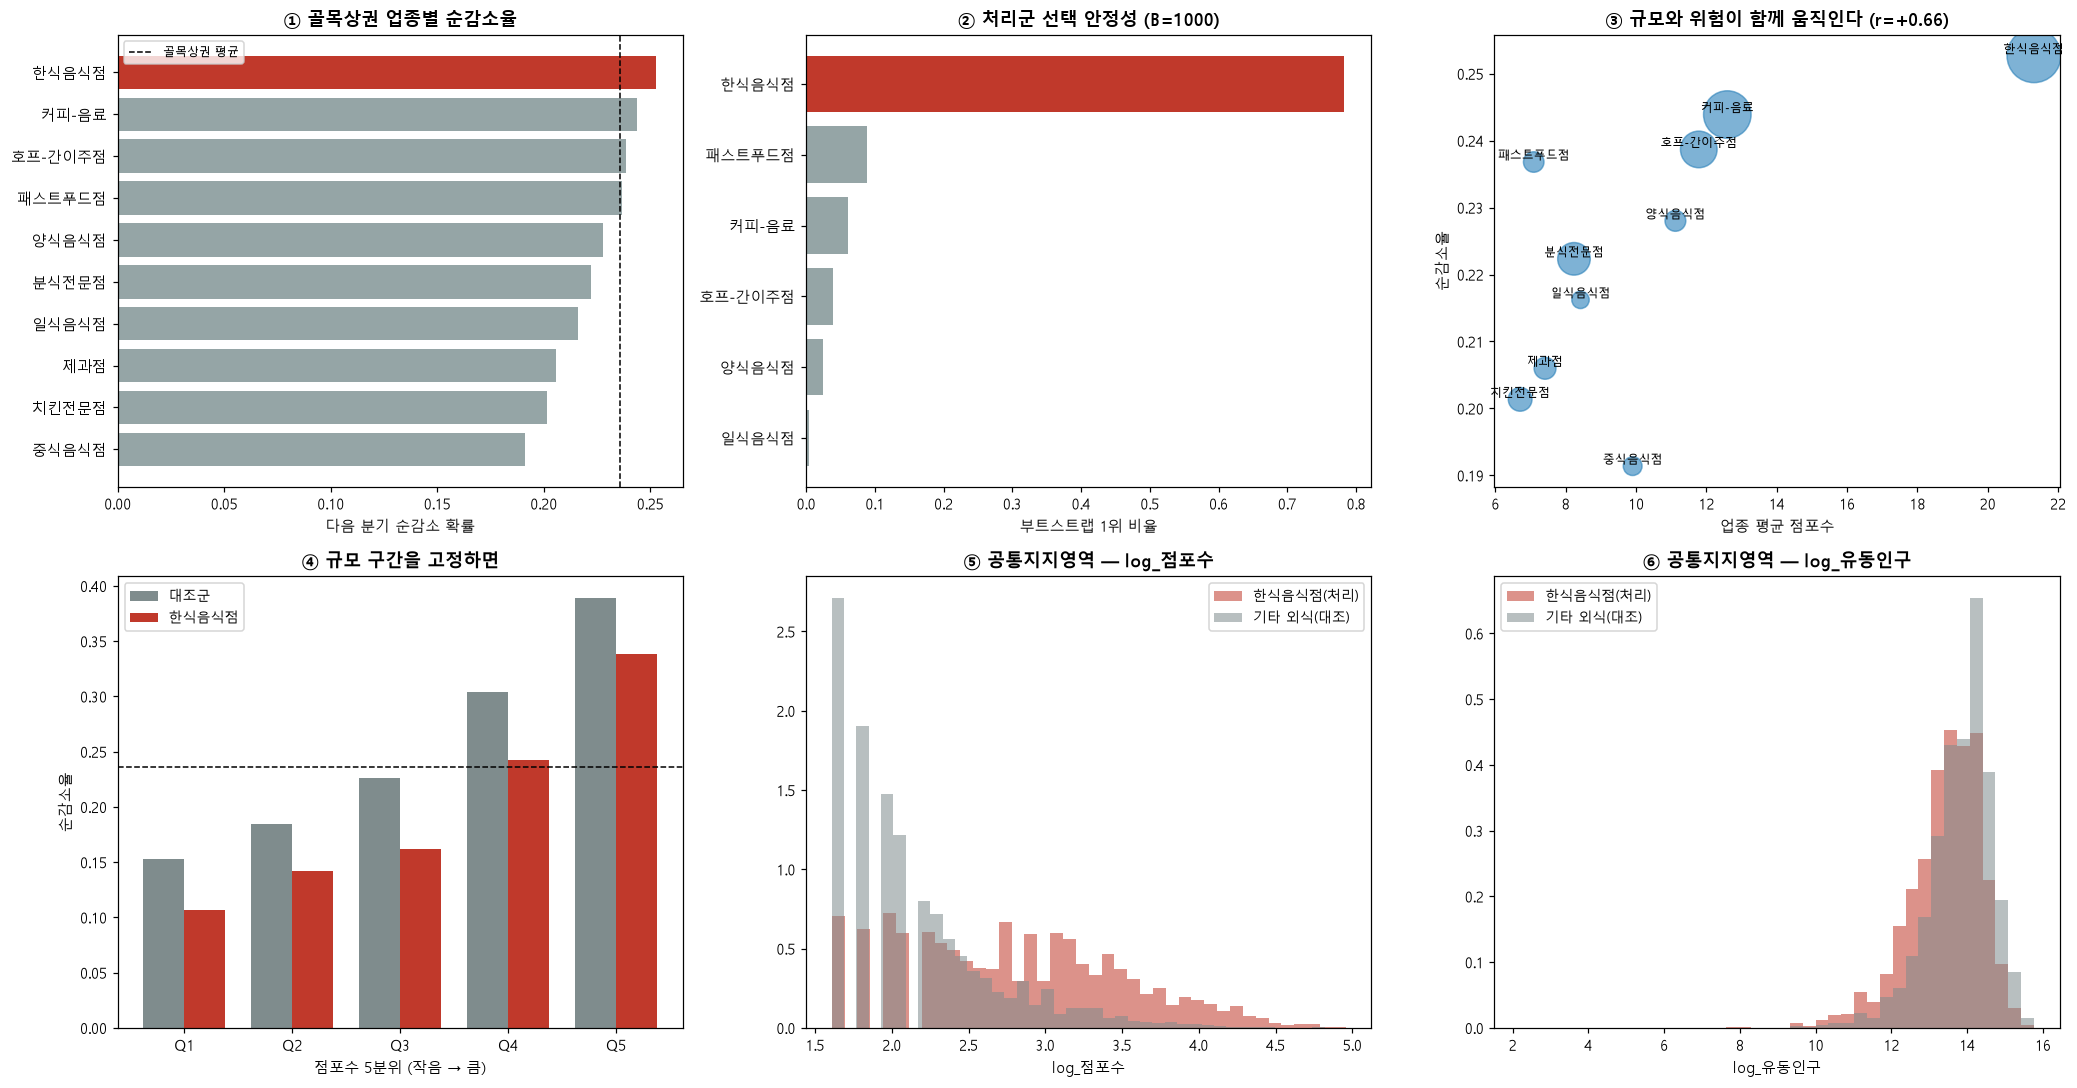

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(19, 10))

# ① 업종별 순감소율
t2 = t.sort_values("순감소율")
colors = ["#c0392b" if i == TREAT else "#95a5a6" for i in t2.index]
ax[0,0].barh(t2.index, t2["순감소율"], color=colors)
ax[0,0].axvline(gm["y"].mean(), ls="--", c="k", lw=1, label=f"{TARGET_TYPE} 평균")
ax[0,0].set_title(f"① {TARGET_TYPE} 업종별 순감소율", weight="bold")
ax[0,0].set_xlabel("다음 분기 순감소 확률"); ax[0,0].legend(fontsize=8)

# ② 처리군 선택 안정성
rs = res["1위 빈도"].sort_values()
rs = rs[rs > 0]
ax[0,1].barh(rs.index, rs.values,
             color=["#c0392b" if i == TREAT else "#95a5a6" for i in rs.index])
ax[0,1].set_xlabel("부트스트랩 1위 비율")
ax[0,1].set_title(f"② 처리군 선택 안정성 (B={B})", weight="bold")

# ③ 규모와 위험
ax[0,2].scatter(t["평균점포"], t["순감소율"], s=t["칸수"]/8, alpha=.6, c="#2980b9")
for i, row in t.iterrows():
    ax[0,2].annotate(i, (row["평균점포"], row["순감소율"]), fontsize=8, ha="center", va="bottom")
ax[0,2].set_xlabel("업종 평균 점포수"); ax[0,2].set_ylabel("순감소율")
ax[0,2].set_title(f"③ 규모와 위험이 함께 움직인다 (r={r:+.2f})", weight="bold")

# ④ 규모 구간별 격차
x = np.arange(len(tbl)); w = 0.38
ax[1,0].bar(x - w/2, tbl["대조군_순감소율"], w, label="대조군", color="#7f8c8d")
ax[1,0].bar(x + w/2, tbl["처리군_순감소율"], w, label=f"{TREAT}", color="#c0392b")
ax[1,0].axhline(gm["y"].mean(), ls="--", c="k", lw=1)
ax[1,0].set_xticks(x); ax[1,0].set_xticklabels(tbl.index)
ax[1,0].set_xlabel("점포수 5분위 (작음 → 큼)"); ax[1,0].set_ylabel("순감소율")
ax[1,0].set_title("④ 규모 구간을 고정하면", weight="bold"); ax[1,0].legend(fontsize=9)

# ⑤⑥ 공통지지영역
for k, c in enumerate(["log_점포수", "log_유동인구"]):
    a = ax[1, 1+k]
    for lab, sub, col in [(f"{TREAT}(처리)", gm[gm["처리"]==1], "#c0392b"),
                          ("기타 외식(대조)", gm[gm["처리"]==0], "#7f8c8d")]:
        a.hist(sub[c], bins=40, alpha=.55, density=True, label=lab, color=col)
    a.set_title(f"{'⑤' if k==0 else '⑥'} 공통지지영역 — {c}", weight="bold")
    a.set_xlabel(c); a.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG / "step5_h2_eda.png", dpi=130)
plt.show()

## 5-9. 저장 및 STEP 6 로 넘기는 것

In [14]:
gm.to_pickle(PROC / "05_golmok.pkl")
mb = (PROC / "05_golmok.pkl").stat().st_size / 1024**2
print(f"[저장] 05_golmok.pkl  {gm.shape}  {mb:.1f} MB  ← STEP 6(PSM) 입력")
print(f"[저장] figures/step5_h2_eda.png\n")

print("── STEP 6 으로 넘기는 것 ──────────────")
print(f"  처리군            : {TREAT}  (부트스트랩 1위 비율 {res.loc[TREAT,'1위 빈도']:.1%})")
print(f"  매칭 전 단순 격차  : {gap:+.1%}p")
print(f"  최대 |SMD|        : {bal['SMD'].abs().max():.3f} ({bal.loc[bal['SMD'].abs().idxmax(),'공변량']})")
print(f"  공통지지 상태     : 4개 공변량 모두 확인 완료")
print()
print("H2 검증 방식: 매칭으로 위 SMD 를 모두 0.1 미만으로 낮춘 뒤,")
print(f"              단순 격차 {gap:+.1%}p 가 어떻게 변하는지 본다.")

[저장] 05_golmok.pkl  (34647, 38)  12.3 MB  ← STEP 6(PSM) 입력
[저장] figures/step5_h2_eda.png

── STEP 6 으로 넘기는 것 ──────────────
  처리군            : 한식음식점  (부트스트랩 1위 비율 78.3%)
  매칭 전 단순 격차  : +2.4%p
  최대 |SMD|        : 0.999 (log_점포수)
  공통지지 상태     : 4개 공변량 모두 확인 완료

H2 검증 방식: 매칭으로 위 SMD 를 모두 0.1 미만으로 낮춘 뒤,
              단순 격차 +2.4%p 가 어떻게 변하는지 본다.


---

## STEP 6 에서 할 일

- 성향점수(공변량 4개 + 분기 더미) 추정 → 공통지지 트리밍
- 분기 고정 1:1 최근접 매칭 (캘리퍼 0.2·SD, 비복원)
- **매칭 후 SMD 균형 검증** — 통과 못 하면 ATT 를 해석하지 않음
- ATT + McNemar + 상권 단위 클러스터 부트스트랩
- 매칭 실패 처리군 진단, 민감도 분석(캘리퍼·복원·시드·자치구 고정)
